In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [3]:
from datetime import datetime, timedelta

from analysis.simulation_values import dataframify
from tests.helpers.collector import PolarsCollector
from tests.helpers.simulation_runner import SimulationTestRunner
from thrs.classes.machine_state_logger import MachineStateLoggingServiceNoop
from thrs.control.modules.adsorption import (
    ADSORPTION_MODULE_DESCRIPTION,
    AdsorptionAlarms,
    AdsorptionControl,
    AdsorptionParameters,
)
from thrs.control.modules.consumers import (
    CONSUMERS_MODULE_DESCRIPTION,
    ConsumersAlarms,
    ConsumersControl,
    ConsumersParameters,
)
from thrs.control.modules.dc import (
    DC_MODULE_DESCRIPTION,
    DcAlarms,
    DcControl,
    DcParameters,
)
from thrs.control.modules.dhw import (
    DHW_MODULE_DESCRIPTION,
    DhwAlarms,
    DhwControl,
    DhwParameters,
)
from thrs.control.modules.drives import (
    DRIVES_MODULE_DESCRIPTION,
    DrivesAlarms,
    DrivesControl,
    DrivesParameters,
)
from thrs.control.modules.pcm import (
    PCM_MODULE_DESCRIPTION,
    PcmAlarms,
    PcmControl,
    PcmParameters,
)
from thrs.control.modules.pvt import (
    PVT_MODULE_DESCRIPTION,
    PvtAlarms,
    PvtControl,
    PvtParameters,
)
from thrs.control.modules.thrusters import (
    THRUSTERS_MODULE_DESCRIPTION,
    ThrustersAlarms,
    ThrustersControl,
    ThrustersParameters,
)
from thrs.input_output.base import CombinedValues, Stamped
from thrs.input_output.definitions.units import PcsMode
from thrs.input_output.modules.adsorption import AdsorptionSensorValues
from thrs.input_output.modules.consumers import ConsumersSensorValues
from thrs.input_output.modules.dc import DcSensorValues
from thrs.input_output.modules.dhw import DhwSensorValues
from thrs.input_output.modules.drives import DrivesSensorValues
from thrs.input_output.modules.pcm import PcmSensorValues
from thrs.input_output.modules.pvt import PvtSensorValues
from thrs.input_output.modules.thrs import (
    ThrsSimulationInputs,
    ThrsSimulationOutputs,
    thrs_cosimulation,
)
from thrs.input_output.modules.thrusters import ThrustersSensorValues
from thrs.orchestration.simulation import Simulation

ThrsSimulationInputsDf = dataframify(ThrsSimulationInputs)

simulation_inputs = ThrsSimulationInputsDf(
    thrusters_thruster_aft={
        "heat_flow": Stamped.stamp(9000), "active": Stamped.stamp(True)
    },
    thrusters_thruster_fwd={
        "heat_flow": Stamped.stamp(4300), "active": Stamped.stamp(True)
    },
    thrusters_seawater_supply={
        "temperature": Stamped.stamp(32), "flow": Stamped.stamp(64)
    },
    thrusters_pcs={"mode": Stamped.stamp(PcsMode.PROPULSION)},
    pvt_main_fwd={"heat_flow": Stamped.stamp(16000)},
    pvt_main_aft={"heat_flow": Stamped.stamp(16000)},
    pvt_owners={"heat_flow": Stamped.stamp(8000)},
    pvt_seawater_supply={"temperature": Stamped.stamp(32), "flow": Stamped.stamp(64)},
    pcm_freshwater_supply={
        "temperature": Stamped.stamp(40), "flow": Stamped.stamp(0)
    },
    adsorption_cooling_supply={"temperature": Stamped.stamp(20.0)},
    adsorption_seawater_supply={
        "temperature": Stamped.stamp(32.0), "flow": Stamped.stamp(64.0)
    },
    adsorption_available_hot_temperature={
        "temperature": Stamped.stamp(65.0)
    },
    adsorption_available_cold_temperature={
        "temperature": Stamped.stamp(20.0)
    },
    adsorption_available_seawater_temperature={
        "temperature": Stamped.stamp(30.0)
    },
    adsorption_chiller={"free_cooling": Stamped.stamp(False)},
    dhw_freshwater_supply={
        "temperature": Stamped.stamp(20), "overpressure": Stamped.stamp(0.1)
    },
    dhw_hvac_exchanger={
        "heat_flow": Stamped.stamp(300), "maximum_temperature": Stamped.stamp(35)
    },
    dhw_seawater_supply={"temperature": Stamped.stamp(32)},
    dhw_hotwater_demand={"flow": Stamped.stamp(20)},
    dc_brightloop_fwd1={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_brightloop_fwd2={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_ugrid1={"heat_flow": Stamped.stamp(2000), "active": Stamped.stamp(True)},
    dc_ugrid2={"heat_flow": Stamped.stamp(2000), "active": Stamped.stamp(True)},
    dc_brightloop_aft1={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_brightloop_aft2={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_brightloop_aft3={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_brightloop_aft4={
        "heat_flow": Stamped.stamp(500), "active": Stamped.stamp(True)
    },
    dc_seawater_supply={"temperature": Stamped.stamp(20), "flow": Stamped.stamp(64)},
    drives_oil_cooler_aft={"heat_flow": Stamped.stamp(0)},
    drives_oil_cooler_fwd={"heat_flow": Stamped.stamp(0)},
    drives_propdrive_aft1={
        "heat_flow": Stamped.stamp(2800), "active": Stamped.stamp(True)
    },
    drives_propdrive_aft2={
        "heat_flow": Stamped.stamp(2800), "active": Stamped.stamp(True)
    },
    drives_propdrive_fwd1={
        "heat_flow": Stamped.stamp(1250), "active": Stamped.stamp(True)
    },
    drives_propdrive_fwd2={
        "heat_flow": Stamped.stamp(1250), "active": Stamped.stamp(True)
    },
    drives_shorepower={
        "heat_flow": Stamped.stamp(0), "active": Stamped.stamp(False)
    },
    drives_seawater_supply={
        "temperature": Stamped.stamp(20), "flow": Stamped.stamp(64)
    },
)
thrs_modules = {
    "thrusters": THRUSTERS_MODULE_DESCRIPTION,
    "pvt": PVT_MODULE_DESCRIPTION,
    "pcm": PCM_MODULE_DESCRIPTION,
    "consumers": CONSUMERS_MODULE_DESCRIPTION,
    "adsorption": ADSORPTION_MODULE_DESCRIPTION,
    "dhw": DHW_MODULE_DESCRIPTION,
    "dc": DC_MODULE_DESCRIPTION,
    "drives": DRIVES_MODULE_DESCRIPTION,
}

parameters = CombinedValues(
    {
        "thrusters": ThrustersParameters(),
        "pvt": PvtParameters(),
        "pcm": PcmParameters(),
        "consumers": ConsumersParameters(),
        "adsorption": AdsorptionParameters(),
        "dhw": DhwParameters(),
        "dc": DcParameters(),
        "drives": DrivesParameters(),
    }
)

with thrs_cosimulation as fmu:
    simulation = Simulation(
        sensor_values_clss={
            "thrusters": ThrustersSensorValues,
            "pvt": PvtSensorValues,
            "pcm": PcmSensorValues,
            "consumers": ConsumersSensorValues,
            "adsorption": AdsorptionSensorValues,
            "dhw": DhwSensorValues,
            "dc": DcSensorValues,
            "drives": DrivesSensorValues,
        },
        simulation_outputs_cls=ThrsSimulationOutputs,
        fmu=fmu,
        simulation_inputs=simulation_inputs,
        start_time=datetime.now(),
        tick_duration=timedelta(seconds=1),
    )
    control = {
        "thrusters": ThrustersControl(
            ThrustersParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "pvt": PvtControl(
            PvtParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "pcm": PcmControl(
            PcmParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "consumers": ConsumersControl(
            ConsumersParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "adsorption": AdsorptionControl(
            AdsorptionParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "dhw": DhwControl(
            DhwParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "dc": DcControl(
            DcParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
        "drives": DrivesControl(
            DrivesParameters(), simulation.time, MachineStateLoggingServiceNoop()
        ),
    }
    alarms = {
        "thrusters": ThrustersAlarms(),
        "pvt": PvtAlarms(),
        "pcm": PcmAlarms(),
        "consumers": ConsumersAlarms(),
        "adsorption": AdsorptionAlarms(),
        "dhw": DhwAlarms(),
        "dc": DcAlarms(),
        "drives": DrivesAlarms(),
    }
    runner = SimulationTestRunner(simulation, simulation_inputs, control, alarms)

    collector = PolarsCollector()
    runner.run(60 * 30, collector)
    result = collector.result()

[WARNING] State logging: Please enable result storing to get state names
[WARNING] State logging: Please enable result storing to get state names
[WARNING] State logging: Please enable result storing to get state names
[WARNING] State logging: Please enable result storing to get state names
[WARNING] State logging: Please enable result storing to get state names


{'adsorption': (<Figure size 1500x700 with 2 Axes>,
  array([<Axes: title={'center': 'ADSORPTION | Temperatures (exchanger traces highlighted)'}, xlabel='time', ylabel='Temperature [C]'>,
         <Axes: title={'center': 'ADSORPTION | Flows (exchanger traces highlighted)'}, xlabel='Time', ylabel='Flow [l/min]'>],
        dtype=object)),
 'consumers': (<Figure size 1500x700 with 2 Axes>,
  array([<Axes: title={'center': 'CONSUMERS | Temperatures (exchanger traces highlighted)'}, xlabel='time', ylabel='Temperature [C]'>,
         <Axes: title={'center': 'CONSUMERS | Flows (exchanger traces highlighted)'}, xlabel='Time', ylabel='Flow [l/min]'>],
        dtype=object)),
 'dc': (<Figure size 1500x700 with 2 Axes>,
  array([<Axes: title={'center': 'DC | Temperatures (exchanger traces highlighted)'}, xlabel='time', ylabel='Temperature [C]'>,
         <Axes: title={'center': 'DC | Flows (exchanger traces highlighted)'}, xlabel='Time', ylabel='Flow [l/min]'>],
        dtype=object)),
 'dhw': (<

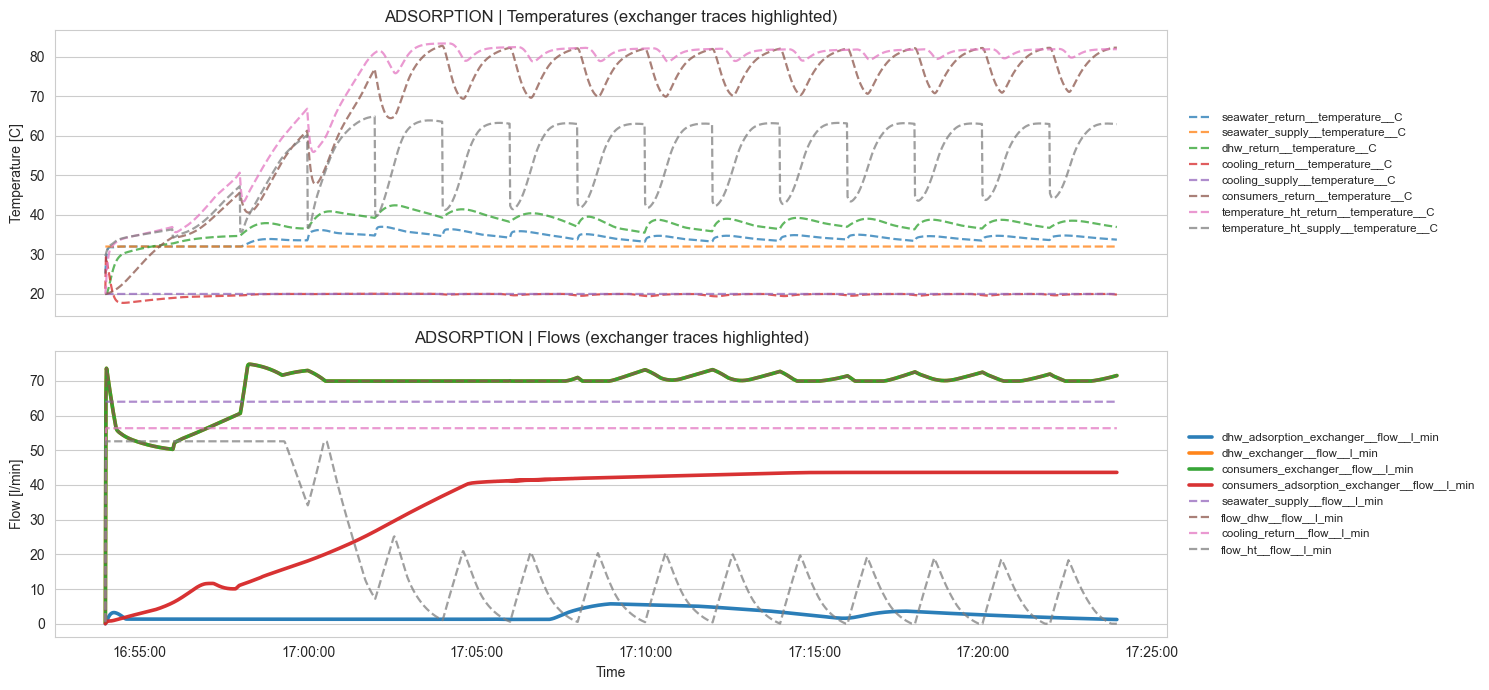

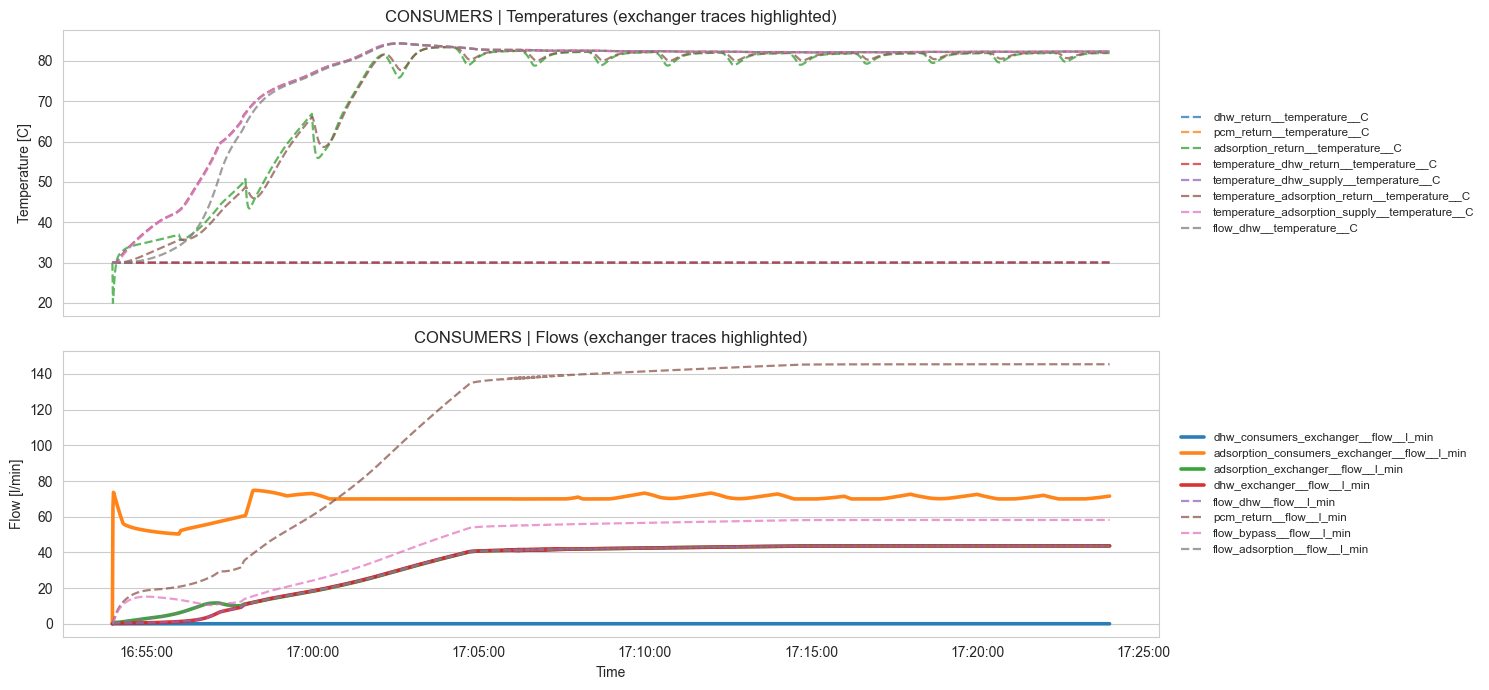

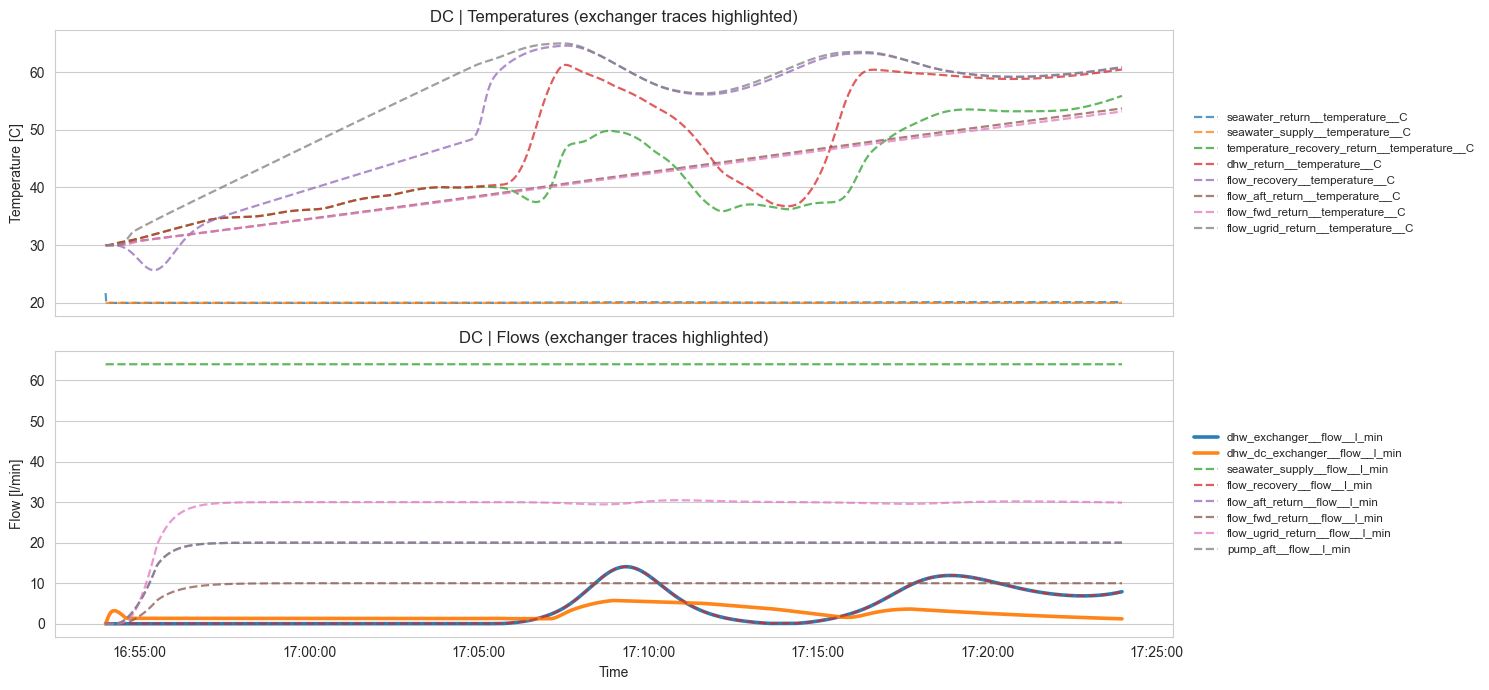

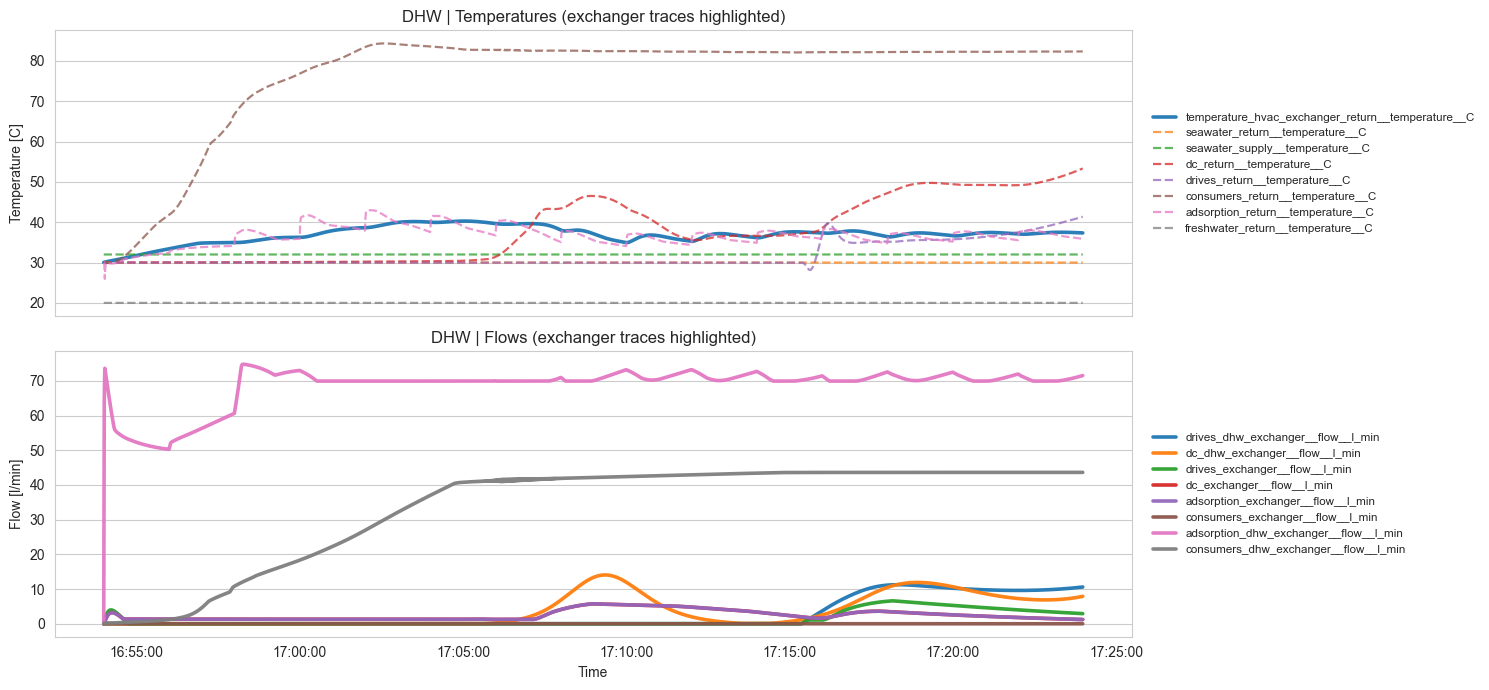

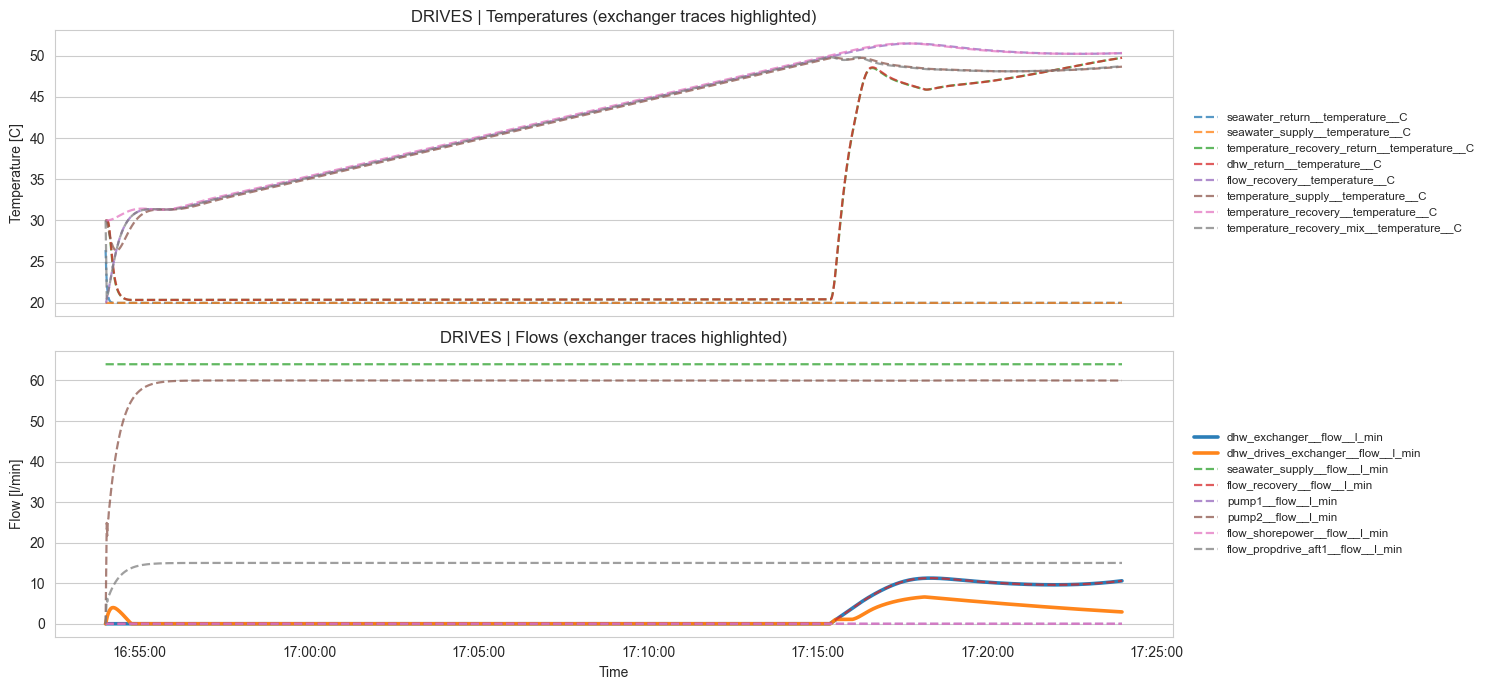

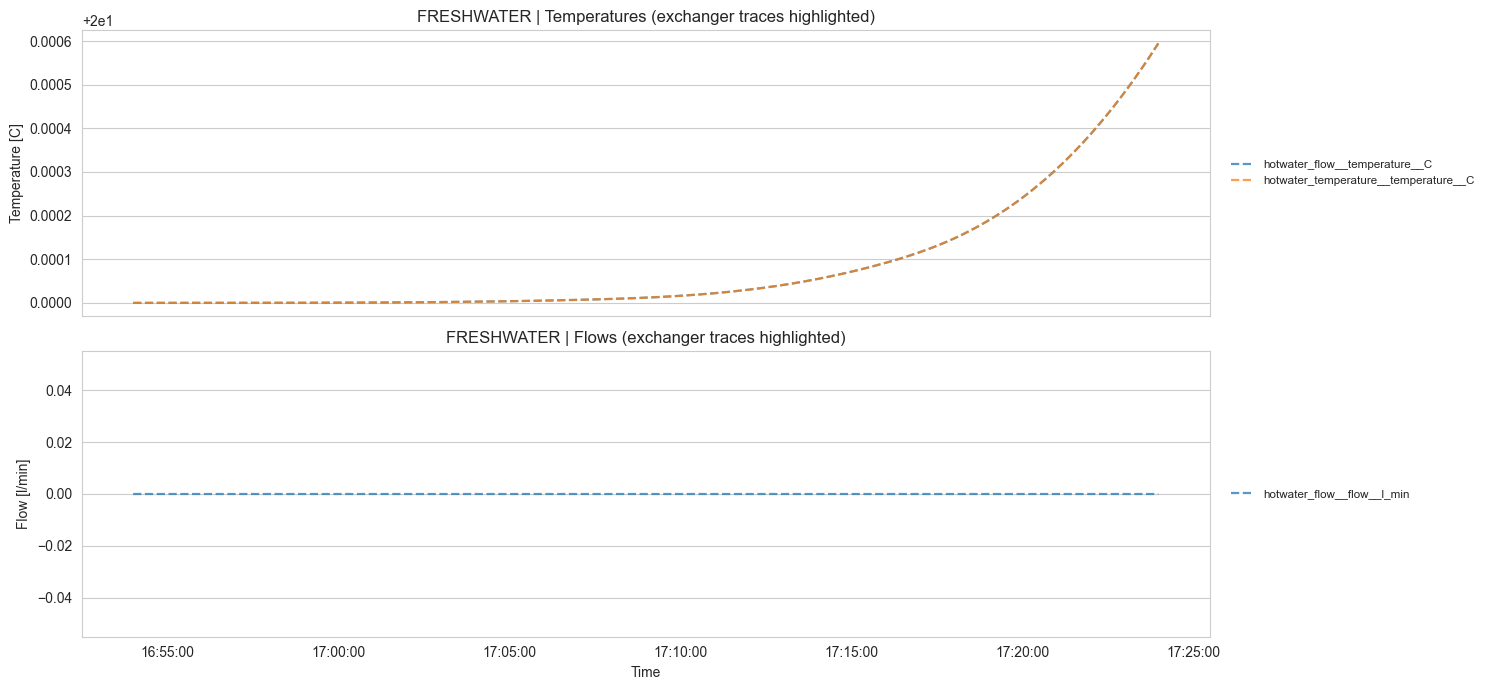

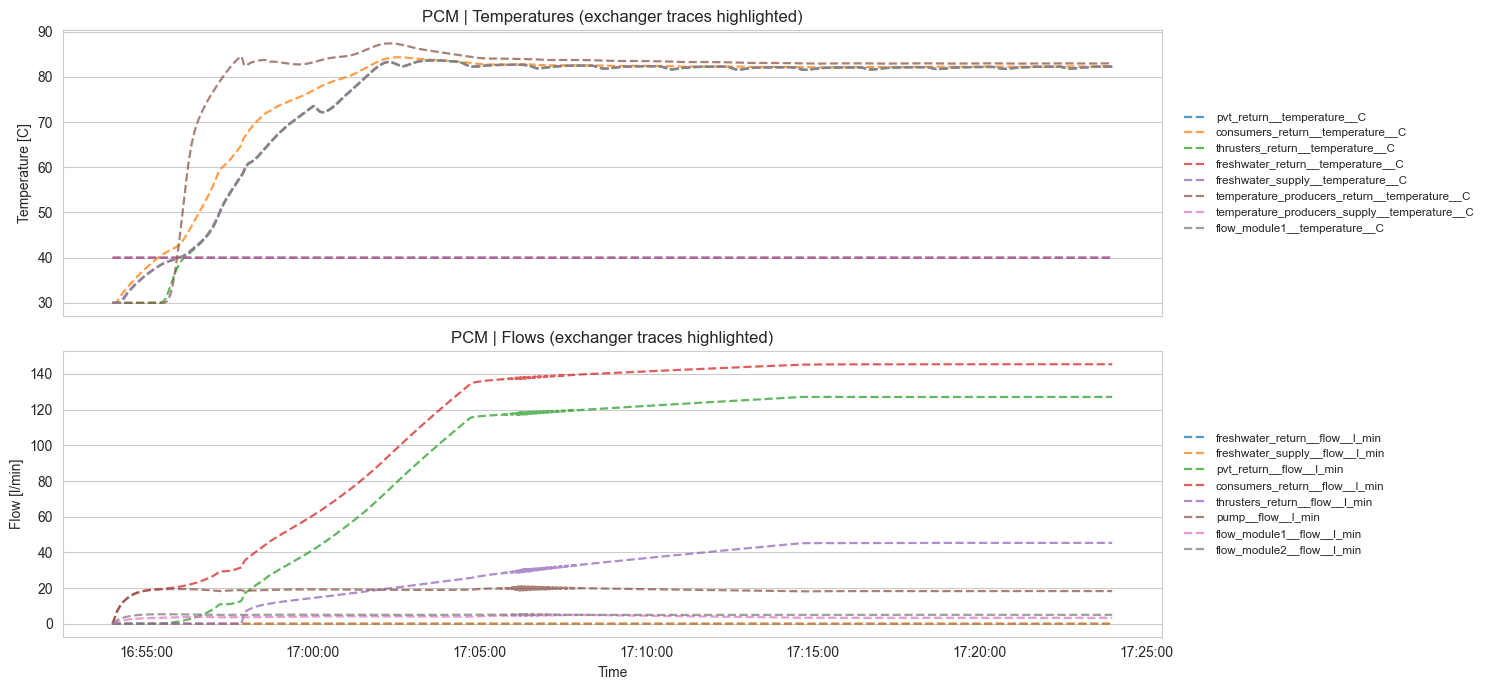

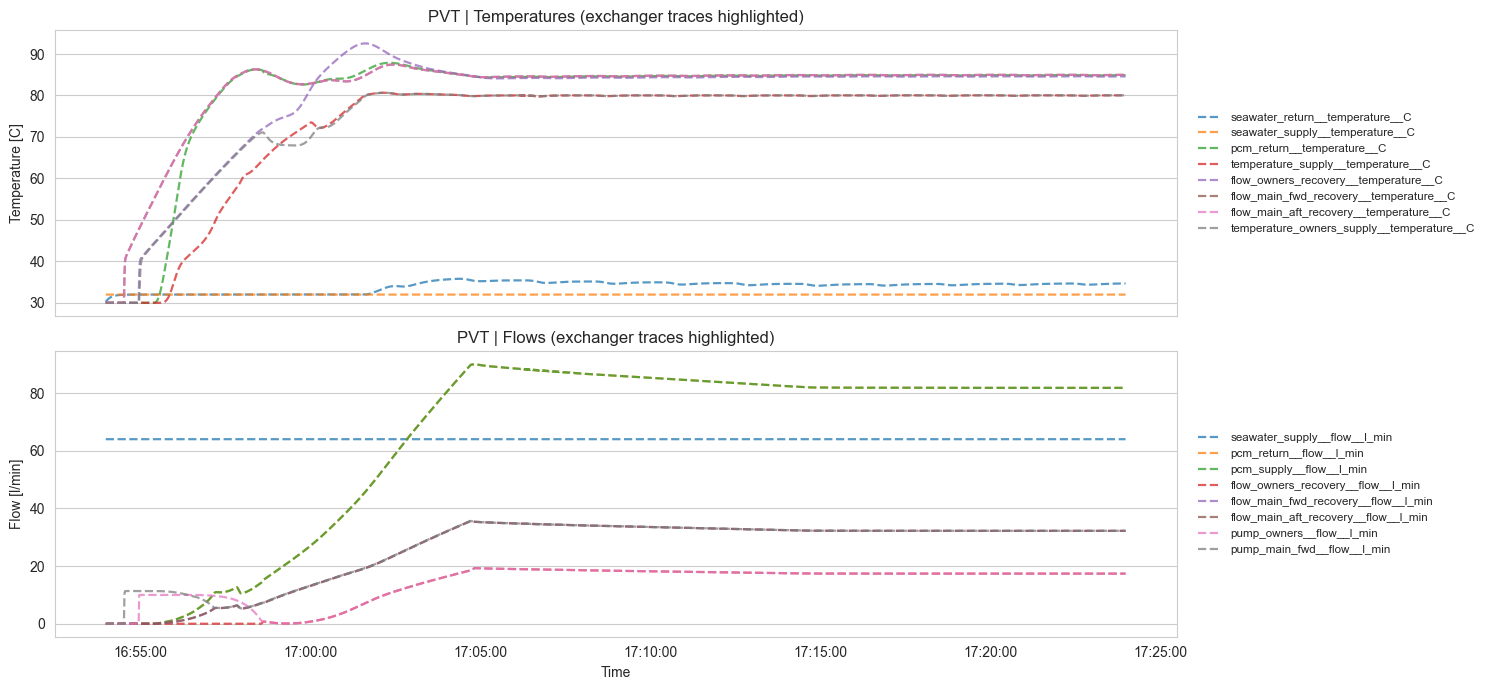

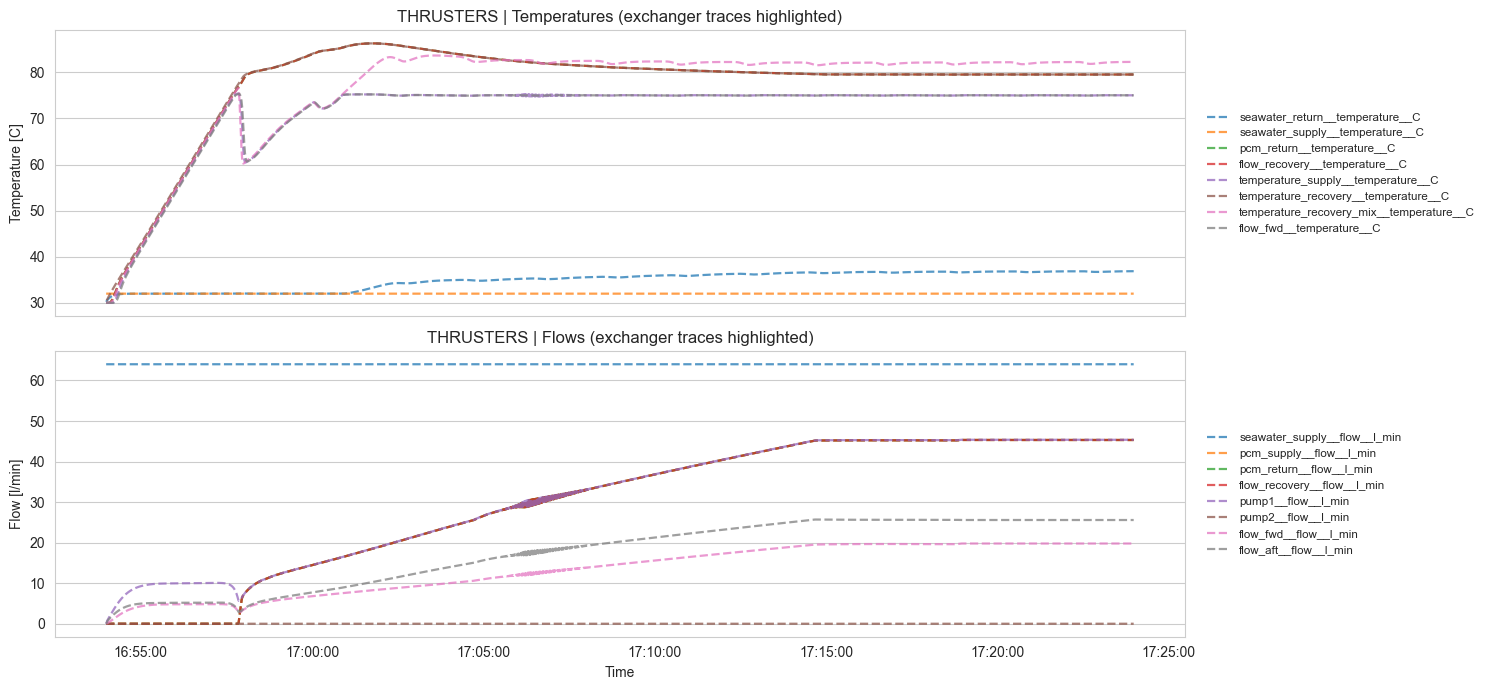

In [4]:
from collections.abc import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns


def _short_name(module: str, col: str) -> str:
    prefix = f"{module}_"
    if col.startswith(prefix):
        return col[len(prefix) :]
    return col


def _ranked(cols: list[str], priority_tokens: list[str], max_n: int) -> list[str]:
    def _score(col: str) -> tuple[int, int, int]:
        hits = sum(token in col for token in priority_tokens)
        exchanger_boost = 100 if "exchanger" in col else 0
        # shorter names are usually cleaner aggregate signals over internals
        return (exchanger_boost + hits, -len(col), -cols.index(col))

    ranked = sorted(cols, key=_score, reverse=True)
    return ranked[:max_n]


def _dedupe(seq: Iterable[str]) -> list[str]:
    seen: set[str] = set()
    out: list[str] = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


def _module_signal_sets(
    all_cols: list[str],
    module: str,
    max_temp: int = 8,
    max_flow: int = 8,
) -> tuple[list[str], list[str]]:
    mod_cols = [c for c in all_cols if c.startswith(f"{module}_")]

    temp_cols = [c for c in mod_cols if "__temperature__" in c and "__flow__" not in c]
    flow_cols = [
        c
        for c in mod_cols
        if "__flow__" in c and "__temperature__" not in c and "string" not in c
    ]

    # Include cross-module exchanger couplings that reference this module
    cross_exchanger_cols = [
        c
        for c in all_cols
        if "exchanger" in c and (c.startswith(f"{module}_") or f"_{module}_" in c)
    ]

    exchanger_temps = [c for c in cross_exchanger_cols if "__temperature__" in c]
    exchanger_flows = [
        c
        for c in cross_exchanger_cols
        if "__flow__" in c and "__temperature__" not in c
    ]

    temp_priority = ["exchanger", "supply", "return", "recovery", "seawater"]
    flow_priority = [
        "exchanger",
        "recovery",
        "supply",
        "return",
        "seawater",
        "freshwater",
        "hotwater",
        "dhw",
    ]

    temp_selected = _dedupe(
        exchanger_temps + _ranked(temp_cols, temp_priority, max_n=max_temp)
    )[:max_temp]
    flow_selected = _dedupe(
        exchanger_flows + _ranked(flow_cols, flow_priority, max_n=max_flow)
    )[:max_flow]

    return temp_selected, flow_selected


def plot_cosim_module_dashboards(
    result: pl.DataFrame,
    modules: list[str] | None = None,
    max_temp: int = 8,
    max_flow: int = 8,
    save_dir: str | None = "plots",
):
    sns.set_style("whitegrid")
    plt.rcParams["axes.grid"] = True
    plt.rcParams["axes.grid.axis"] = "y"

    pdf = result.to_pandas().set_index("time")
    all_cols = [c for c in pdf.columns if c != "control_mode"]

    if modules is None:
        modules = sorted({c.split("_", 1)[0] for c in all_cols if "_" in c})

    figs = {}
    for module in modules:
        temp_cols, flow_cols = _module_signal_sets(
            all_cols, module, max_temp=max_temp, max_flow=max_flow
        )

        fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
        panels = [
            (axes[0], temp_cols, "Temperature [C]"),
            (axes[1], flow_cols, "Flow [l/min]"),
        ]

        for ax, cols, ylabel in panels:
            if cols:
                panel_df = pdf[cols].rename(
                    columns={c: _short_name(module, c) for c in cols}
                )

                for col in panel_df.columns:
                    is_exchanger = "exchanger" in col
                    sns.lineplot(
                        x=panel_df.index,
                        y=panel_df[col],
                        ax=ax,
                        linewidth=2.6 if is_exchanger else 1.6,
                        alpha=0.95 if is_exchanger else 0.75,
                        linestyle="-" if is_exchanger else "--",
                        label=col,
                    )

                ax.legend(
                    loc="center left",
                    bbox_to_anchor=(1.01, 0.5),
                    frameon=False,
                    fontsize="small",
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    "No signals",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    alpha=0.7,
                )

            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

        axes[0].set_title(
            f"{module.upper()} | Temperatures (exchanger traces highlighted)"
        )
        axes[1].set_title(f"{module.upper()} | Flows (exchanger traces highlighted)")
        axes[1].set_xlabel("Time")

        plt.tight_layout()
        if save_dir:
            fig.savefig(
                f"{save_dir}/thrs_{module}_dashboard.png",
                bbox_inches="tight",
                dpi=250,
            )

        figs[module] = (fig, axes)

    return figs


dashboards = plot_cosim_module_dashboards(result)
dashboards